Jonnatan Arias Garcia

jonnanta.arias@utp.edu.co

jariasg@uniquindio.edu.co

#Prediction GPs

Regresión con Procesos Gaussianos (GPs)
**Objetivo**: Predecir una función no lineal usando procesos gaussianos con kernel RBF.

## 1. Generación de Datos
 **Función verdadera**:
$ [ y(x) = \sin(2\pi x) ]$
 **Observaciones con ruido**:
$[ t = y(x) + \epsilon,\quad \epsilon \sim \mathcal{N}(0, \beta^{-1}) ]$
 donde $(\beta = 1/\sigma^2 = 100)$

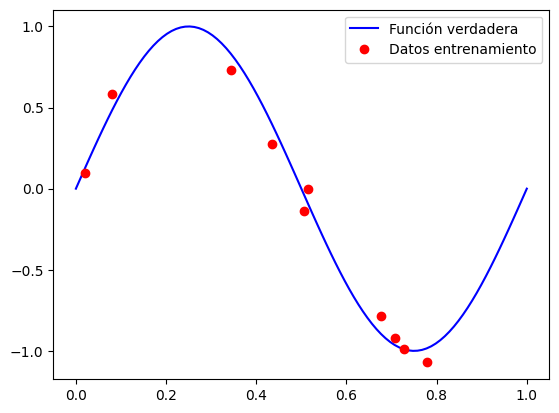

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10**4)  # Reproducibilidad

# Configuración
N_tot = 100
sigma2 = 0.01
beta = 1/sigma2
betaInv = 1/beta

# Generar datos
x_tot = np.linspace(0, 1, num=N_tot)[:, np.newaxis]
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(betaInv)*np.random.randn(N_tot)[:, np.newaxis]

# Split train/test
N = 10
index = np.random.permutation(N_tot)
x, t = x_tot[index[:N]], t_tot[index[:N]]

# Visualización
fig, ax = plt.subplots()
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x, t, '.r', markersize=12, label='Datos entrenamiento')
ax.legend()
plt.show()

## 2. Definición del Kernel RBF
 **Función de covarianza**:
$[
 k(x, x') = \sigma_f^2 \exp\left(-\frac{\|x - x'\|^2}{2l^2}\right)
]$
- $(l)$: Parámetro de longitud (suavidad)
- $(\sigma_f^2)$: Varianza de la señal

In [2]:
def rbfKernel(x, xp, l, sf):
    """
    x: (n, 1)
    xp: (m, 1)
    Retorna: (n, m)
    """
    sq_dist = x**2 - 2*x@xp.T + (xp.T**2)  # (x - x')² para todos los pares
    return sf*np.exp(-sq_dist/(2*l**2))

## 3. Matriz de Covarianza y Descomposición de Cholesky

 **Matriz de covarianza**:
$[
 K = k(X, X) + \beta^{-1}I
]$

 **Estabilidad numérica**:
 Usamos descomposición de Cholesky para invertir $(K)$:
$[
 K = LL^T \Rightarrow K^{-1} = (L^{-1})^T L^{-1}
]$


In [3]:
l = 0.1      # Longitud característica
sf = 0.5     # Escala de la señal

# Covarianza entre puntos de entrenamiento
K = rbfKernel(x, x, l, sf)
K += betaInv*np.eye(N)  # Agregar ruido a la diagonal

# Descomposición de Cholesky
L = np.linalg.cholesky(K)
Linv = np.linalg.solve(L, np.eye(N))

## 4. Predicción con GPs
**Ecuaciones de predicción**:

 **Media predictiva**:
$[
 \mu_* = K(X_*, X)[K(X, X) + \beta^{-1}I]^{-1}\mathbf{t} ]$

 **Covarianza predictiva**:
$[
 \Sigma_* = K(X_*, X_*) - K(X_*, X)[K(X, X) + \beta^{-1}I]^{-1}K(X, X_*) + \beta^{-1}I
]$

In [4]:
# Covarianza entre test y train
K_star = rbfKernel(x_tot, x, l, sf)

# Media predictiva
alpha = Linv.T @ Linv @ t  # = K^{-1}t
mu_pred = K_star @ alpha

# Covarianza predictiva
K_starstar = rbfKernel(x_tot, x_tot, l, sf)
cov_pred = K_starstar - K_star @ (Linv.T @ Linv) @ K_star.T
cov_pred += betaInv*np.eye(N_tot)  # Agregar ruido a la diagonal

# Varianza (diagonal de cov_pred)
var_pred = np.diag(cov_pred)

## 5. Visualización de Resultados
**Intervalos de confianza**:
Mostramos la media ± 2 desviaciones estándar $((\sim 95\%) de probabilidad)$

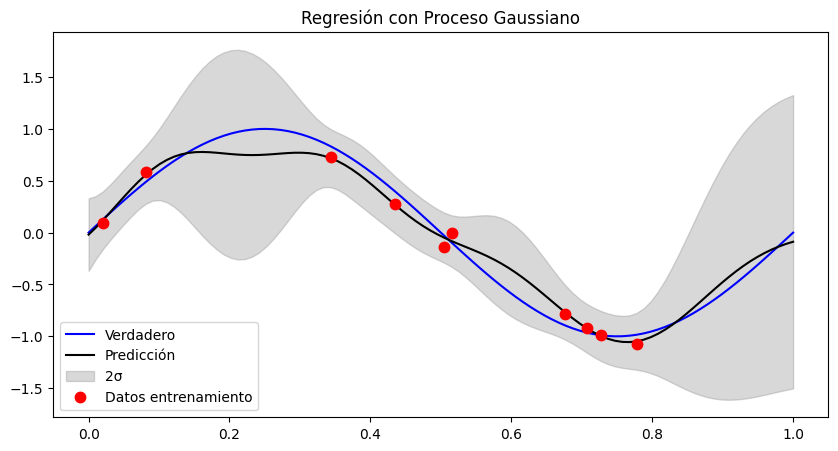

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_tot, y_tot, 'b', label='Verdadero')
ax.plot(x_tot, mu_pred, 'k', label='Predicción')
ax.fill_between(x_tot.flatten(),
                mu_pred.flatten() - 2*np.sqrt(var_pred),
                mu_pred.flatten() + 2*np.sqrt(var_pred),
                alpha=0.3, color='gray', label='2σ')
ax.plot(x, t, '.r', markersize=15, label='Datos entrenamiento')
ax.set_title('Regresión con Proceso Gaussiano')
ax.legend()
plt.show()

## 6. Interpretación de Parámetros
- **$(l=0.1)$**: Suaviza demasiado (subajuste)
 - **$(\sigma_f=0.5)$**: Escala insuficiente

 **Solución**:
 Optimizar hiperparámetros maximizando la verosimilitud marginal:
$[
 \log p(\mathbf{t}|X) = -\frac{1}{2}\mathbf{t}^TK^{-1}\mathbf{t} - \frac{1}{2}\log|K| - \frac{n}{2}\log 2\pi
]$

## 7. Ventajas de los GPs
1. **Incertidumbre calibrada**: Intervalos confiables
2. **No linealidad flexible**: Kernel RBF captura patrones complejos
3. **Sin sobreajuste**: Regularización natural vía kernel

#Predicción GP usando sklearn

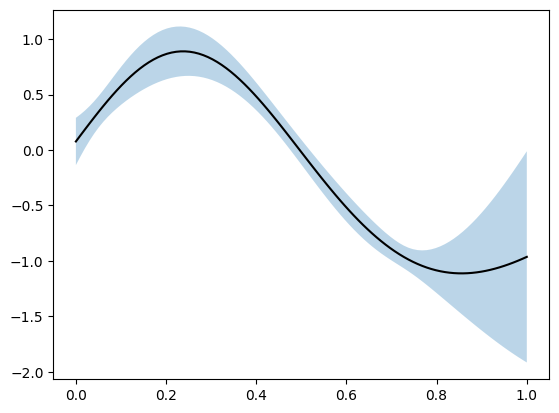

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Definir kernel RBF
kernel = RBF(length_scale=0.1, length_scale_bounds=(1e-2, 10.0))

# Crear modelo GP
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.01,  # Ruido (sigma^2)
    n_restarts_optimizer=10
)

# Entrenar y predecir
gp.fit(x, t)
mu_pred, std_pred = gp.predict(x_tot, return_std=True)

# Graficar
plt.plot(x_tot, mu_pred, 'k')
plt.fill_between(x_tot.flatten(), mu_pred-2*std_pred, mu_pred+2*std_pred, alpha=0.3)

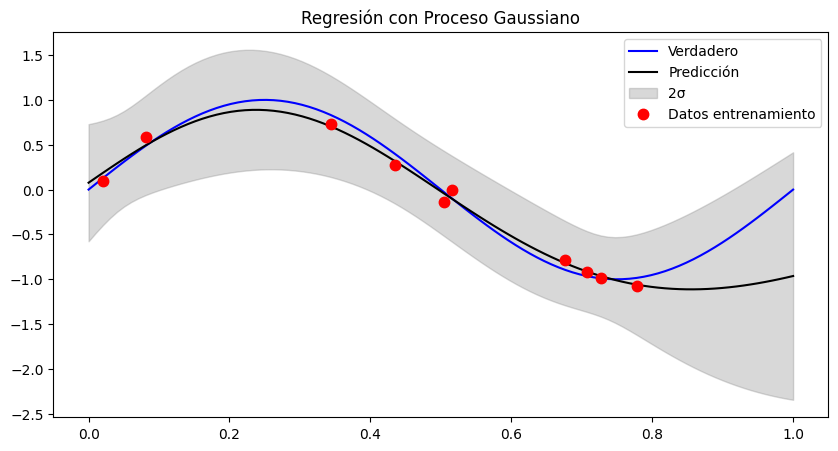

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_tot, y_tot, 'b', label='Verdadero')
ax.plot(x_tot, mu_pred, 'k', label='Predicción')
ax.fill_between(x_tot.flatten(),
                mu_pred.flatten() - 2*np.sqrt(std_pred),
                mu_pred.flatten() + 2*np.sqrt(std_pred),
                alpha=0.3, color='gray', label='2σ')
ax.plot(x, t, '.r', markersize=15, label='Datos entrenamiento')
ax.set_title('Regresión con Proceso Gaussiano')
ax.legend()
plt.show()

# Muestreo de Funciones en Procesos Gaussianos
**Objetivo**: Generar muestras de un Proceso Gaussiano (GP) usando un kernel RBF para entender su comportamiento a priori.

## 1. Configuración Inicial
 Definimos puntos en el intervalo [0,1] para evaluar el GP:
$ [
 x \in [0,1], \quad x_p \in [0,1]
]$
 - `Nx = 100`: Número de puntos de evaluación
 - `l = 0.1`: Parámetro de longitud del kernel
 - `sf = 1`: Factor de escala del kernel

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(10**4)  # Semilla para reproducibilidad

Nx = 100
x = np.linspace(0, 1, num=Nx)[:, np.newaxis]
xp = np.linspace(0, 1, num=Nx)[:, np.newaxis]

## 2. Definición del Kernel RBF
**Función de covarianza**:
$[
 k(x,x') = \sigma_f^2 \exp\left(-\frac{(x-x')^2}{2l^2}\right)
]$

 Implementación vectorizada vs. por loops:

In [14]:
def rbfKernel(x, xp, l, sf):
    """
    Versión vectorizada eficiente
    x: (N,1), xp: (M,1) -> K: (N,M)
    """
    sq_dist = x**2 - 2*x@xp.T + xp.T**2  # (x - x')²
    return sf * np.exp(-sq_dist/(2*l**2))

## 3. Matriz de Covarianza
Calculamos la matriz K donde:
$[
 K_{ij} = k(x_i, x_j)
]$

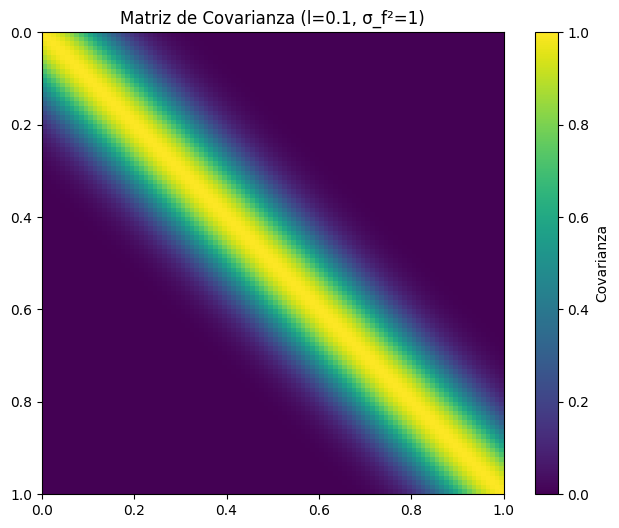

In [15]:
l = 0.1   # Longitud característica
sf = 1    # Varianza de la señal
K = rbfKernel(x, xp, l, sf)

# Visualización
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(K, extent=[0,1,1,0], cmap='viridis')
plt.colorbar(im, label='Covarianza')
ax.set_title(f'Matriz de Covarianza (l={l}, σ_f²={sf})')
plt.show()

## 4. Muestreo de Funciones del GP
 Generamos muestras de la distribución gaussiana multivariada:
$[
 \mathbf{f} \sim \mathcal{N}(\mathbf{0}, K)
 ]$
 Cada muestra es una función completa!


In [16]:
nsamples = 5
mean = np.zeros(Nx)
samples = multivariate_normal.rvs(mean, K, nsamples)

## 5. Visualización de las Muestras
Cada línea representa una realización diferente del GP:

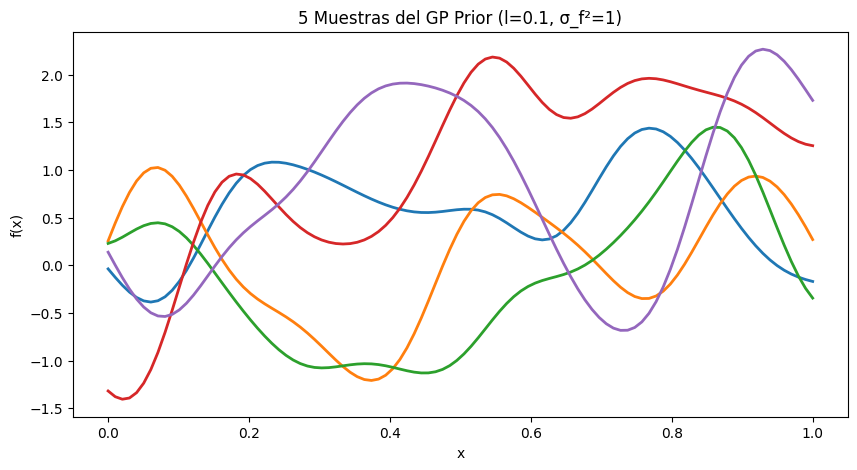

In [18]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x, samples.T, linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'{nsamples} Muestras del GP Prior (l={l}, σ_f²={sf})')
plt.show()

## 6. Interpretación de Resultados
- **l=0.1**: Funciones muy "oscilantes" (poca suavidad)
 - **σ_f²=1**: Escala típica de las fluctuaciones

 **Efecto de los parámetros**:
* | Parámetro | Efecto en las muestras |
* |-------------------|--------------------------------------|
* | **l** ↑ ------------- | Funciones más suaves     |
* | **σ_f²** ↑ -------- | Mayor amplitud         -----------|


## 7. Pipeline del Proceso
```mermaid
graph TD
     A[Definir dominio x] --> B[Calcular matriz K]
     B --> C[Muestrear de N(0,K)]
     C --> D[Visualizar funciones]
```

## 8. ¿Para qué sirve esto?
 1. **Entender kernels**: Ver cómo afectan parámetros
 2. **Chequear modelos**: Validar implementaciones de GPs
 3. **Análisis de sensibilidad**: Estudiar efecto de hiperparámetros



#Muestreo usando Sklearn

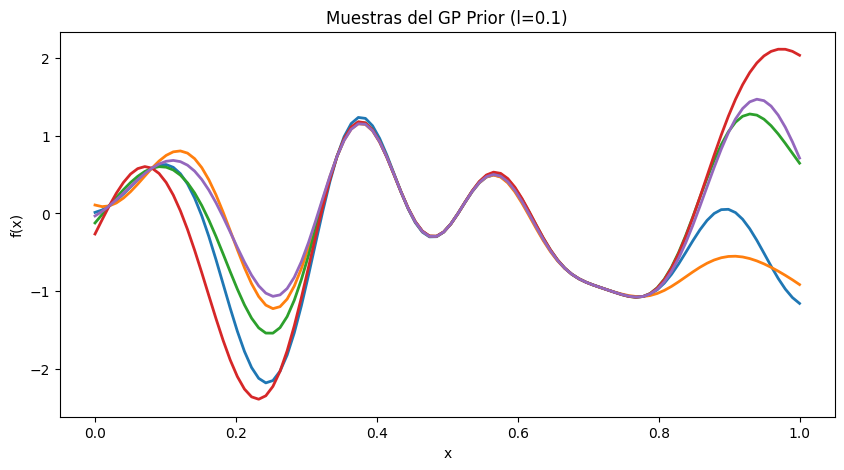

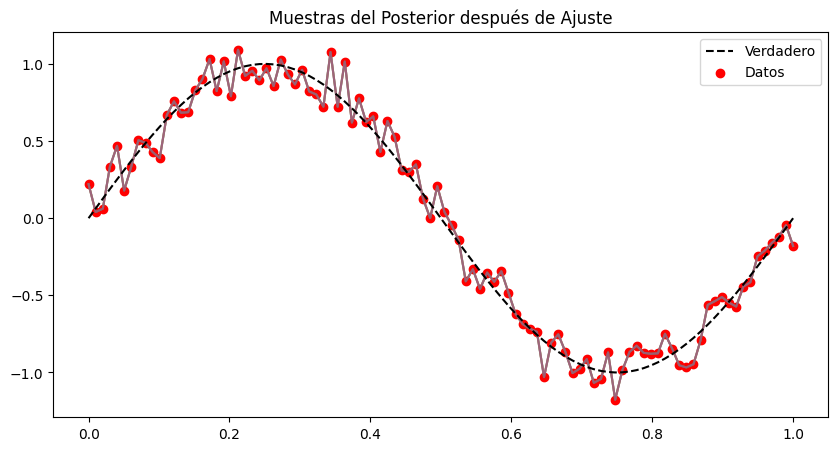

In [21]:
# ## 1. Configuración Inicial
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

np.random.seed(10**4)

# Puntos de evaluación
np.random.seed(10**4)  # Reproducibilidad

# Configuración
N_tot = 100
sigma2 = 0.01
beta = 1/sigma2
betaInv = 1/beta

# Generar datos
x_tot = np.linspace(0, 1, num=N_tot)[:, np.newaxis]
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(betaInv)*np.random.randn(N_tot)[:, np.newaxis]

# Split train/test
N = 10
index = np.random.permutation(N_tot)
x, t = x_tot[index[:N]], t_tot[index[:N]]


# ## 2. Definición del Kernel
# **Parámetros fijos** (sin optimizar):
kernel = RBF(length_scale=0.1, length_scale_bounds="fixed")

# ## 3. Creación del Modelo GP
# **Importante**: Desactivar la optimización de hiperparámetros
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0,          # Sin ruido observacional
    optimizer=None,    # No optimizar hiperparámetros
    normalize_y=False
)

# ## 4. Muestreo de Funciones
# sklearn requiere un "fit" aunque no usemos datos
gp.fit(x,t)  # Truco: ajuste dummy

# Generar muestras
n_samples = 5
samples = gp.sample_y(X, n_samples)


# ## 5. Visualización
plt.figure(figsize=(10, 5))
plt.plot(X, samples, linewidth=2)
plt.title(f'Muestras del GP Prior (l=0.1)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

# ## 6. Muestreo con Hiperparámetros Optimizados
# Ejemplo completo con datos reales:
# Generar datos observados
f_true = np.sin(2*np.pi*X)
y = f_true + np.random.normal(0, 0.1, size=X.shape)

# Crear GP con kernel optimizable
kernel_opt = RBF(length_scale=0.1)
gp_opt = GaussianProcessRegressor(kernel_opt, n_restarts_optimizer=10)

# Ajustar a datos
gp_opt.fit(X, y)

# Muestrear posterior
posterior_samples = gp_opt.sample_y(X, n_samples=5)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(X, posterior_samples, alpha=0.5)
plt.plot(X, f_true, 'k--', label='Verdadero')
plt.scatter(X, y, c='r', label='Datos')
plt.legend()
plt.title('Muestras del Posterior después de Ajuste')
plt.show()